In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv("/content/ACLED Data_2026-03-08.csv")


In [3]:
data = data[["event_id_cnty", "country", "event_date", "disorder_type", "event_type",
             "interaction", "civilian_targeting", "region", "notes",
             "fatalities"]]
data


,event_id_cnty,country,event_date,disorder_type,event_type,interaction,civilian_targeting,region,notes,fatalities
0,BUR3027,Burundi,2015-01-01,Political violence,Battles,State forces-Political militia,NaN,Eastern Africa,Fighting between unidentified attackers believ...,21
1,GAM103,Gambia,2015-01-01,Political violence,Violence against civilians,State forces-Civilians,Civilian targeting,Western Africa,Five people reportedly abducted by men believe...,0
2,SUD7377,Sudan,2015-01-01,Political violence,Violence against civilians,Political militia-Civilians,Civilian targeting,Northern Africa,Unidentified actors attack the civilian popula...,0
3,NIG6859,Nigeria,2015-01-01,Political violence,Explosions/Remote violence,Political militia-Civilians,Civilian targeting,Western Africa,A suicide bomber blew himself up at the gates ...,1
4,YEM32556,Yemen,2015-01-01,Political violence,Explosions/Remote violence,Political militia-Political militia,NaN,Middle East,Member of the popular committees in Abyan repo...,0
...,...,...,...,...,...,...,...,...,...,...
831646,NIG47528,Nigeria,2025-03-08,Political violence,Violence against civilians,Political militia-Civilians,Civilian targeting,Western Africa,"On 8 March 2025, an unidentified group armed w...",0
831647,NIG47529,Nigeria,2025-03-08,Political violence,Violence against civilians,Identity militia-Civilians,Civilian targeting,Western Africa,"On 8 March 2025, a Katsina militia wounded two...",0
831648,NIG47530,Nigeria,2025-03-08,Political violence,Violence against civilians,Identity militia-Civilians,Civilian targeting,Western Africa,"On 8 March 2025, a Katsina militia killed 2 co...",2
831649,NIG47531,Nigeria,2025-03-08,Political violence,Battles,State forces-Rebel group,NaN,Western Africa,"On 8 March 2025, ISWAP/Boko Haram (JAS) fighte...",2


In [4]:
data["event_date"] = pd.to_datetime(data["event_date"])
data = data.sort_values(by=["country", "event_date"]).reset_index(drop=True)


In [5]:
# Drop columns with too many NaN values or not useful for modelling
data = data.drop(columns=["civilian_targeting", "event_id_cnty", "region", "disorder_type"])
data


,country,event_date,event_type,interaction,notes,fatalities
0,Albania,2018-02-06,Explosions/Remote violence,Political militia only,"On Feb. 6, 2018: An explosion occurred near th...",0
1,Albania,2018-02-06,Explosions/Remote violence,Political militia only,"On Feb. 6, 2018: An explosion occurred in a bu...",0
2,Albania,2018-02-06,Explosions/Remote violence,Political militia only,"On Feb. 6, 2018: An explosion with TNT occurre...",0
3,Albania,2018-02-12,Riots,Rioters-External/Other forces,"On Feb. 12, 2018: National theater artists for...",0
4,Albania,2018-03-21,Riots,State forces-Rioters,"On Mar. 21, 2018: Miners demonstrated in front...",0
...,...,...,...,...,...,...
831646,Yemen,2025-03-08,Battles,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0
831647,Yemen,2025-03-08,Battles,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0
831648,Yemen,2025-03-08,Battles,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0
831649,Yemen,2025-03-08,Battles,State forces-State forces,"On 8 March 2025, Houthi forces clashed with th...",0


In [6]:
df = pd.get_dummies(data, columns=["event_type"], dtype=int)
df


,country,event_date,interaction,notes,fatalities,event_type_Battles,event_type_Explosions/Remote violence,event_type_Protests,event_type_Riots,event_type_Strategic developments,event_type_Violence against civilians
0,Albania,2018-02-06,Political militia only,"On Feb. 6, 2018: An explosion occurred near th...",0,0,1,0,0,0,0
1,Albania,2018-02-06,Political militia only,"On Feb. 6, 2018: An explosion occurred in a bu...",0,0,1,0,0,0,0
2,Albania,2018-02-06,Political militia only,"On Feb. 6, 2018: An explosion with TNT occurre...",0,0,1,0,0,0,0
3,Albania,2018-02-12,Rioters-External/Other forces,"On Feb. 12, 2018: National theater artists for...",0,0,0,0,1,0,0
4,Albania,2018-03-21,State forces-Rioters,"On Mar. 21, 2018: Miners demonstrated in front...",0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
831646,Yemen,2025-03-08,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0
831647,Yemen,2025-03-08,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0
831648,Yemen,2025-03-08,State forces-Political militia,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0
831649,Yemen,2025-03-08,State forces-State forces,"On 8 March 2025, Houthi forces clashed with th...",0,1,0,0,0,0,0


In [7]:
df[["actor1", "actor2"]] = df["interaction"].str.split("-", expand=True)
df["actor1"] = df["actor1"].str.replace(" only", "", regex=False)
df["actor2"] = df["actor2"].str.replace(" only", "", regex=False)


In [8]:
actor1_dummies = pd.get_dummies(df["actor1"], prefix="actor", dtype=int)
actor2_dummies = pd.get_dummies(df["actor2"], prefix="actor", dtype=int)
actor_features = actor1_dummies.add(actor2_dummies, fill_value=0)

df = pd.concat([df, actor_features], axis=1)
df = df.drop(["interaction", "actor1", "actor2"], axis=1)
df


,country,event_date,notes,fatalities,event_type_Battles,event_type_Explosions/Remote violence,event_type_Protests,event_type_Riots,event_type_Strategic developments,event_type_Violence against civilians,actor_Civilians,actor_External/Other forces,actor_Identity militia,actor_Political militia,actor_Protesters,actor_Rebel group,actor_Rioters,actor_State forces
0,Albania,2018-02-06,"On Feb. 6, 2018: An explosion occurred near th...",0,0,1,0,0,0,0,0.0,0,0,1,0,0,0,0
1,Albania,2018-02-06,"On Feb. 6, 2018: An explosion occurred in a bu...",0,0,1,0,0,0,0,0.0,0,0,1,0,0,0,0
2,Albania,2018-02-06,"On Feb. 6, 2018: An explosion with TNT occurre...",0,0,1,0,0,0,0,0.0,0,0,1,0,0,0,0
3,Albania,2018-02-12,"On Feb. 12, 2018: National theater artists for...",0,0,0,0,1,0,0,0.0,1,0,0,0,0,1,0
4,Albania,2018-03-21,"On Mar. 21, 2018: Miners demonstrated in front...",0,0,0,0,1,0,0,0.0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831646,Yemen,2025-03-08,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0,0.0,0,0,1,0,0,0,1
831647,Yemen,2025-03-08,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0,0.0,0,0,1,0,0,0,1
831648,Yemen,2025-03-08,"On 8 March 2025, Houthi forces exchanged limit...",0,1,0,0,0,0,0,0.0,0,0,1,0,0,0,1
831649,Yemen,2025-03-08,"On 8 March 2025, Houthi forces clashed with th...",0,1,0,0,0,0,0,0.0,0,0,0,0,0,0,2


## BERT Embeddings for Event Notes
BERT embeddings are computed per event (row) on the `notes` column before weekly aggregation.
This is safe — each event's text is embedded independently; no future information is used.


In [9]:
# !pip install sentence-transformers  # Uncomment if not installed

from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = bert_model.encode(
    df["notes"].fillna("").tolist(),
    batch_size=64,
    show_progress_bar=True
)

embeddings_df = pd.DataFrame(
    embeddings,
    columns=[f"bert_{i}" for i in range(embeddings.shape[1])]
)

df = pd.concat([df.reset_index(drop=True), embeddings_df], axis=1)
df = df.drop(columns=["notes"])  # notes no longer needed; captured in embeddings
df


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


...

[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


[Progress bar — run cell to see live output]


,country,event_date,fatalities,event_type_Battles,event_type_Explosions/Remote violence,event_type_Protests,event_type_Riots,event_type_Strategic developments,event_type_Violence against civilians,actor_Civilians,...,bert_374,bert_375,bert_376,bert_377,bert_378,bert_379,bert_380,bert_381,bert_382,bert_383
0,Albania,2018-02-06,0,0,1,0,0,0,0,0.0,...,0.067318,-0.079349,0.000961,0.002978,-0.014745,-0.019325,0.034108,0.009476,0.001720,0.029705
1,Albania,2018-02-06,0,0,1,0,0,0,0,0.0,...,-0.025172,-0.050843,-0.008566,-0.047572,0.050793,-0.062165,0.077797,-0.033391,-0.032597,0.031741
2,Albania,2018-02-06,0,0,1,0,0,0,0,0.0,...,0.015565,-0.013258,-0.032057,-0.046443,0.006573,-0.009546,0.098966,-0.044275,0.051180,-0.039614
3,Albania,2018-02-12,0,0,0,0,1,0,0,0.0,...,0.030683,-0.042630,0.020646,0.084593,-0.006899,0.062060,-0.020137,-0.013739,-0.018947,0.014590
4,Albania,2018-03-21,0,0,0,0,1,0,0,0.0,...,0.038387,0.069379,-0.003454,-0.008091,-0.078032,-0.015307,0.084890,0.017045,0.025673,0.005045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831646,Yemen,2025-03-08,0,1,0,0,0,0,0,0.0,...,-0.038827,0.049014,0.003194,-0.105476,0.007446,0.027957,0.070493,-0.088566,-0.008623,0.036188
831647,Yemen,2025-03-08,0,1,0,0,0,0,0,0.0,...,-0.038827,0.049014,0.003194,-0.105476,0.007446,0.027957,0.070493,-0.088566,-0.008623,0.036188
831648,Yemen,2025-03-08,0,1,0,0,0,0,0,0.0,...,-0.024118,0.059113,-0.018744,-0.080311,0.031739,0.019432,0.062205,-0.099429,-0.019831,0.042576
831649,Yemen,2025-03-08,0,1,0,0,0,0,0,0.0,...,-0.035415,-0.017813,-0.016127,-0.086400,-0.061292,0.042258,0.032181,-0.022386,-0.061937,0.062313


## Weekly Aggregation
Group events by (country, week) to get one row per country per week.
- Fatalities: summed
- Actor / event-type one-hot columns: summed (counts per week)
- BERT embeddings: averaged across events in the week


In [10]:
df["week"] = df["event_date"].dt.to_period("W")

bert_cols        = [c for c in df.columns if c.startswith("bert_")]
actor_cols       = [c for c in df.columns if c.startswith("actor_")]
event_type_cols  = [c for c in df.columns if c.startswith("event_type_")]

weekly_df = df.groupby(["country", "week"]).agg(
    {
        "fatalities": "sum",
        **{col: "sum"  for col in actor_cols},
        **{col: "sum"  for col in event_type_cols},
        **{col: "mean" for col in bert_cols},
    }
).reset_index()

weekly_df


,country,week,fatalities,actor_Civilians,actor_External/Other forces,actor_Identity militia,actor_Political militia,actor_Protesters,actor_Rebel group,actor_Rioters,...,bert_374,bert_375,bert_376,bert_377,bert_378,bert_379,bert_380,bert_381,bert_382,bert_383
0,Albania,2018-02-05/2018-02-11,0,0.0,0,0,3,0,0,0,...,0.019237,-0.047817,-0.013221,-0.030345,0.014207,-0.030345,0.070290,-0.022730,0.006768,0.007278
1,Albania,2018-02-12/2018-02-18,0,0.0,1,0,0,0,0,1,...,0.030683,-0.042630,0.020646,0.084593,-0.006899,0.062060,-0.020137,-0.013739,-0.018947,0.014590
2,Albania,2018-03-19/2018-03-25,0,0.0,0,0,0,0,0,1,...,0.038387,0.069379,-0.003454,-0.008091,-0.078032,-0.015307,0.084890,0.017045,0.025673,0.005045
3,Albania,2018-03-26/2018-04-01,0,0.0,0,0,0,0,0,1,...,0.038443,-0.061690,0.079270,0.004470,-0.009050,0.059872,0.071281,0.007691,0.010038,0.043835
4,Albania,2018-04-02/2018-04-08,0,0.0,0,0,0,0,0,1,...,0.035939,0.010542,0.006103,0.041892,-0.006535,0.064892,0.031918,0.049323,0.056222,-0.041394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23211,Yemen,2025-02-03/2025-02-09,58,13.0,1,12,12,1,6,0,...,-0.008491,-0.001391,-0.013751,-0.073231,-0.010990,0.022180,0.055803,-0.044646,-0.037609,0.037086
23212,Yemen,2025-02-10/2025-02-16,76,17.0,8,20,7,2,4,0,...,0.001304,-0.001871,-0.011666,-0.069733,-0.009855,0.030890,0.058891,-0.038530,-0.033843,0.035615
23213,Yemen,2025-02-17/2025-02-23,82,19.0,4,0,15,2,2,0,...,-0.009478,0.005719,-0.016513,-0.074042,-0.014091,0.024586,0.060278,-0.047999,-0.034228,0.036019
23214,Yemen,2025-02-24/2025-03-02,26,15.0,1,10,18,1,5,0,...,-0.008499,0.002336,-0.018436,-0.071040,-0.007614,0.029603,0.053267,-0.046563,-0.043508,0.033473


## Feature Engineering
All engineered features are derived from *current or past* data only — no future information is used here.


In [11]:
# Total event count per week
weekly_df["event_count"] = weekly_df[event_type_cols].sum(axis=1)

# Violent event sub-total and ratio
weekly_df["violent_events"] = (
    weekly_df["event_type_Battles"] +
    weekly_df["event_type_Explosions/Remote violence"] +
    weekly_df["event_type_Violence against civilians"]
)
weekly_df["violent_event_ratio"] = (
    weekly_df["violent_events"] / weekly_df["event_count"].replace(0, 1)
)

# State-actor ratio
weekly_df["state_actor_ratio"] = (
    weekly_df["actor_State forces"] /
    weekly_df[[
        "actor_Civilians", "actor_External/Other forces",
        "actor_Identity militia", "actor_Political militia",
        "actor_Protesters", "actor_Rebel group",
        "actor_Rioters", "actor_State forces"
    ]].sum(axis=1).replace(0, 1)
)

# Event diversity (number of distinct event types in the week)
weekly_df["event_diversity"] = (weekly_df[event_type_cols] > 0).sum(axis=1)

weekly_df.head()


,country,week,fatalities,actor_Civilians,actor_External/Other forces,actor_Identity militia,actor_Political militia,actor_Protesters,actor_Rebel group,actor_Rioters,...,bert_379,bert_380,bert_381,bert_382,bert_383,event_count,violent_events,violent_event_ratio,state_actor_ratio,event_diversity
0,Albania,2018-02-05/2018-02-11,0,0.0,0,0,3,0,0,0,...,-0.030345,0.070290,-0.022730,0.006768,0.007278,3,3,1.0,0.0,1
1,Albania,2018-02-12/2018-02-18,0,0.0,1,0,0,0,0,1,...,0.062060,-0.020137,-0.013739,-0.018947,0.014590,1,0,0.0,0.0,1
2,Albania,2018-03-19/2018-03-25,0,0.0,0,0,0,0,0,1,...,-0.015307,0.084890,0.017045,0.025673,0.005045,1,0,0.0,0.5,1
3,Albania,2018-03-26/2018-04-01,0,0.0,0,0,0,0,0,1,...,0.059872,0.071281,0.007691,0.010038,0.043835,1,0,0.0,0.5,1
4,Albania,2018-04-02/2018-04-08,0,0.0,0,0,0,0,0,1,...,0.064892,0.031918,0.049323,0.056222,-0.041394,1,0,0.0,0.5,1


## Lag Features  *(data-leakage fix)*
**Bug fixed:** The original code used `.rolling(N)` which included the *current* week in the window,
so `fatalities_lag2` at week *t* was actually `fatalities[t-1] + fatalities[t]`.
That is not a lag — it leaks current-week data into the feature.

**Fix:** Sort by week, then use `.shift(1).rolling(N)` so that at week *t*:
- `fatalities_lag2` = sum of weeks *t-1* and *t-2*
- `fatalities_lag4` = sum of weeks *t-1* through *t-4*


In [12]:
# Sort within each country by week before computing rolling windows
weekly_df = weekly_df.sort_values(["country", "week"]).reset_index(drop=True)

# Shift by 1 FIRST so that week-t only sees history up to week t-1
weekly_df["fatalities_lag2"] = (
    weekly_df.groupby("country")["fatalities"]
    .transform(lambda s: s.shift(1).rolling(2, min_periods=1).sum())
)

weekly_df["fatalities_lag4"] = (
    weekly_df.groupby("country")["fatalities"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=1).sum())
)

weekly_df[["country", "week", "fatalities", "fatalities_lag2", "fatalities_lag4"]].head(10)


,country,week,fatalities,fatalities_lag2,fatalities_lag4
0,Albania,2018-02-05/2018-02-11,0,NaN,NaN
1,Albania,2018-02-12/2018-02-18,0,0.0,0.0
2,Albania,2018-03-19/2018-03-25,0,0.0,0.0
3,Albania,2018-03-26/2018-04-01,0,0.0,0.0
4,Albania,2018-04-02/2018-04-08,0,0.0,0.0
5,Albania,2018-05-21/2018-05-27,0,0.0,0.0
6,Albania,2018-06-11/2018-06-17,0,0.0,0.0
7,Albania,2018-08-27/2018-09-02,0,0.0,0.0
8,Albania,2018-09-17/2018-09-23,0,0.0,0.0
9,Albania,2018-09-24/2018-09-30,0,0.0,0.0


## Target Variable: Conflict Escalation  *(data-leakage fix)*
`future_fatalities` is computed as the sum of fatalities over the *next 4 weeks*.
`conflict_escalation = 1` if future fatalities > 2× current week's fatalities.

**Bug fixed (original code):**
- `future_fatalities` was left as a column in `X`, directly encoding the label → **severe leakage**.
- `fillna(0)` was applied *after* training, so NaN rows (last 4 weeks per country,
  where future is unknown) were silently included with a NaN label → **corrupted labels**.

**Fix:**
- `future_fatalities` is used only to compute the label, then **dropped**.
- Rows where `conflict_escalation` is NaN (last 4 weeks per country, no future) are **dropped before splitting**.


In [13]:
# future_fatalities: used ONLY to derive the label, then dropped
weekly_df["future_fatalities"] = (
    weekly_df.groupby("country")["fatalities"].shift(-1) +
    weekly_df.groupby("country")["fatalities"].shift(-2) +
    weekly_df.groupby("country")["fatalities"].shift(-3) +
    weekly_df.groupby("country")["fatalities"].shift(-4)
)

weekly_df["conflict_escalation"] = (
    weekly_df["future_fatalities"] > 2 * weekly_df["fatalities"]
).astype("Int64")   # Int64 preserves NaN for rows that have no future window

# Drop future_fatalities — it must NEVER enter the feature matrix
weekly_df = weekly_df.drop(columns=["future_fatalities"])

# Drop rows where the label is NaN (last 4 weeks per country — future is unknown)
weekly_df = weekly_df.dropna(subset=["conflict_escalation"]).reset_index(drop=True)
weekly_df["conflict_escalation"] = weekly_df["conflict_escalation"].astype(int)

print("Label distribution:")
print(weekly_df["conflict_escalation"].value_counts())
weekly_df.head()


Label distribution:
conflict_escalation
1    14751
0     8465
Name: count, dtype: int64


,country,week,fatalities,actor_Civilians,actor_External/Other forces,actor_Identity militia,actor_Political militia,actor_Protesters,actor_Rebel group,actor_Rioters,...,bert_382,bert_383,event_count,violent_events,violent_event_ratio,state_actor_ratio,event_diversity,fatalities_lag2,fatalities_lag4,conflict_escalation
0,Albania,2018-02-05/2018-02-11,0,0.0,0,0,3,0,0,0,...,0.006768,0.007278,3,3,1.0,0.0,1,NaN,NaN,0
1,Albania,2018-02-12/2018-02-18,0,0.0,1,0,0,0,0,1,...,-0.018947,0.014590,1,0,0.0,0.0,1,0.0,0.0,0
2,Albania,2018-03-19/2018-03-25,0,0.0,0,0,0,0,0,1,...,0.025673,0.005045,1,0,0.0,0.5,1,0.0,0.0,0
3,Albania,2018-03-26/2018-04-01,0,0.0,0,0,0,0,0,1,...,0.010038,0.043835,1,0,0.0,0.5,1,0.0,0.0,0
4,Albania,2018-04-02/2018-04-08,0,0.0,0,0,0,0,0,1,...,0.056222,-0.041394,1,0,0.0,0.5,1,0.0,0.0,0


## Temporal Train / Test Split  *(data-leakage fix)*
**Bug fixed:** `train_test_split(..., shuffle=False)` split rows in their stored order.
Because the DataFrame is sorted by *country first then week*, the "test" rows end up being
the last countries alphabetically — not the most recent time period. This mixes future and
past data across the split boundary.

**Fix:** Split on the **time axis** — train on weeks before a cutoff, test on weeks after.
This mirrors real-world use where the model is trained on historical data and evaluated on future data.


In [14]:
from sklearn.model_selection import train_test_split

# Convert Period to timestamp for comparison
weekly_df["week_ts"] = weekly_df["week"].dt.to_timestamp()

# Use 80th percentile of weeks as the cutoff (80 / 20 time split)
cutoff = weekly_df["week_ts"].quantile(0.80)
print(f"Train: weeks up to {cutoff.date()}   |   Test: weeks after {cutoff.date()}")

train_df = weekly_df[weekly_df["week_ts"] <= cutoff].copy()
test_df  = weekly_df[weekly_df["week_ts"] >  cutoff].copy()

print(f"Train size: {len(train_df)}   Test size: {len(test_df)}")

# Drop non-feature columns from X
drop_cols = ["conflict_escalation", "country", "week", "week_ts"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["conflict_escalation"]

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df["conflict_escalation"]

print("\nFeature matrix shape — Train:", X_train.shape, "  Test:", X_test.shape)


Train: weeks up to 2023-06-26   |   Test: weeks after 2023-06-26
Train size: 18592   Test size: 4624

Feature matrix shape — Train: (18592, 406)   Test: (4624, 406)


## Fill Remaining NaNs
The only remaining NaNs are in `fatalities_lag2` / `fatalities_lag4` for the first few weeks of
each country (not enough history yet). We fill those with 0 *separately on train and test*
to avoid any cross-contamination.


In [15]:
# Fill NaNs only in lag features; do it separately on train and test
lag_cols = ["fatalities_lag2", "fatalities_lag4"]
X_train[lag_cols] = X_train[lag_cols].fillna(0)
X_test[lag_cols]  = X_test[lag_cols].fillna(0)

# Sanity check — no NaNs should remain
assert X_train.isnull().sum().sum() == 0, "NaNs remain in X_train!"
assert X_test.isnull().sum().sum()  == 0, "NaNs remain in X_test!"
print("No NaNs remaining. Ready for modelling.")


No NaNs remaining. Ready for modelling.


## Model Training — XGBoost Classifier


In [16]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

clf.fit(X_train, y_train)
print("Model trained.")


Model trained.


## Evaluation


In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


              precision    recall  f1-score   support

           0       0.77      0.71      0.74      1911
           1       0.81      0.85      0.83      2713

    accuracy                           0.79      4624
   macro avg       0.79      0.78      0.78      4624
weighted avg       0.79      0.79      0.79      4624

ROC-AUC: 0.8623


## Conflict Risk Index
Scale predicted probabilities to a 0-100 risk index.


In [18]:
test_df = test_df.copy()
test_df["risk_index"] = y_proba * 100

# Top-10 highest-risk country-weeks
test_df[["country", "week", "fatalities", "conflict_escalation", "risk_index"]] \
    .sort_values("risk_index", ascending=False) \
    .head(10)


,country,week,fatalities,conflict_escalation,risk_index
2278,Brazil,2023-10-09/2023-10-15,142,1,99.392601
2283,Brazil,2023-11-13/2023-11-19,157,1,99.292229
2282,Brazil,2023-11-06/2023-11-12,147,1,99.291138
2271,Brazil,2023-08-21/2023-08-27,141,1,99.279587
2320,Brazil,2024-07-29/2024-08-04,134,1,99.267235
2290,Brazil,2024-01-01/2024-01-07,159,1,99.241051
2284,Brazil,2023-11-20/2023-11-26,143,1,99.238083
2277,Brazil,2023-10-02/2023-10-08,165,1,99.232239
2269,Brazil,2023-08-07/2023-08-13,157,1,99.222458
2295,Brazil,2024-02-05/2024-02-11,152,1,99.211182


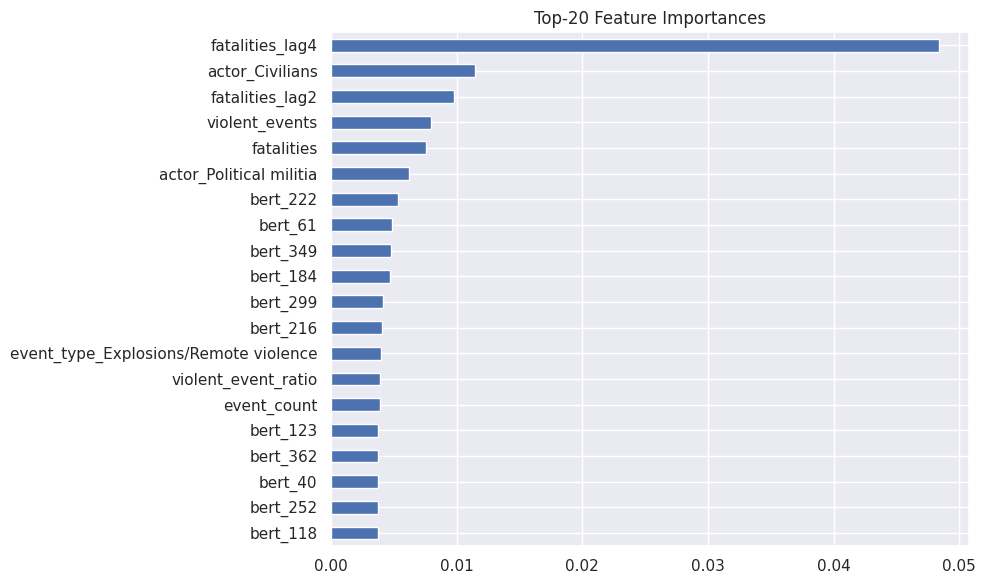

In [19]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh")
plt.title("Top-20 Feature Importances")
plt.tight_layout()
plt.show()


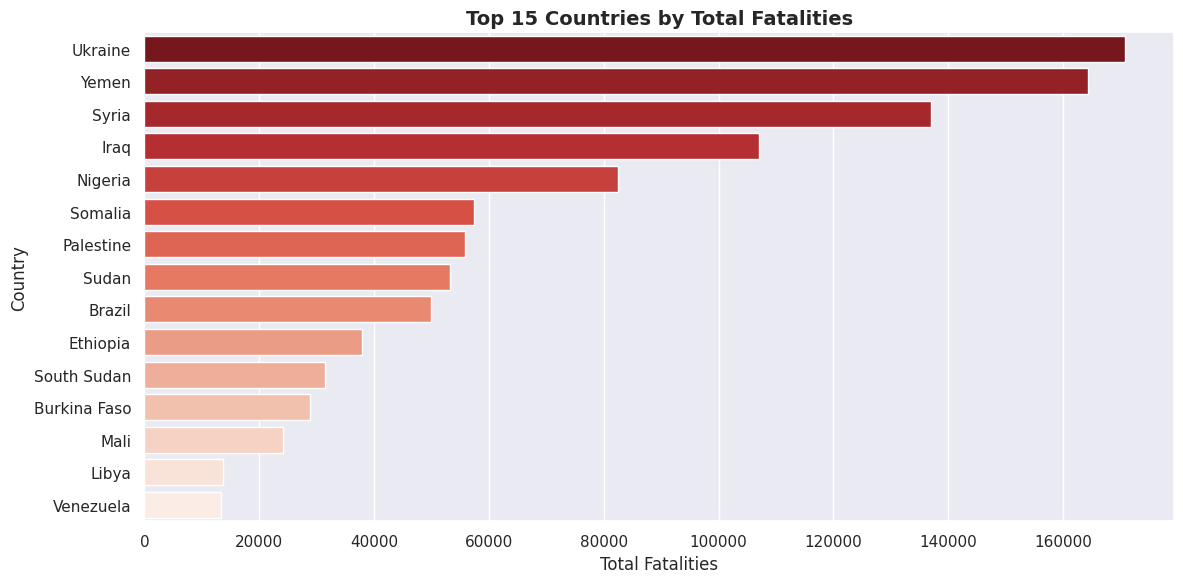

In [20]:
# 1. TOP COUNTRIES BY FATALITIES (Bar Chart)
# ─────────────────────────────────────────────
top_countries = (
    weekly_df.groupby("country")["fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r")
plt.title("Top 15 Countries by Total Fatalities", fontsize=14, fontweight="bold")
plt.xlabel("Total Fatalities")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

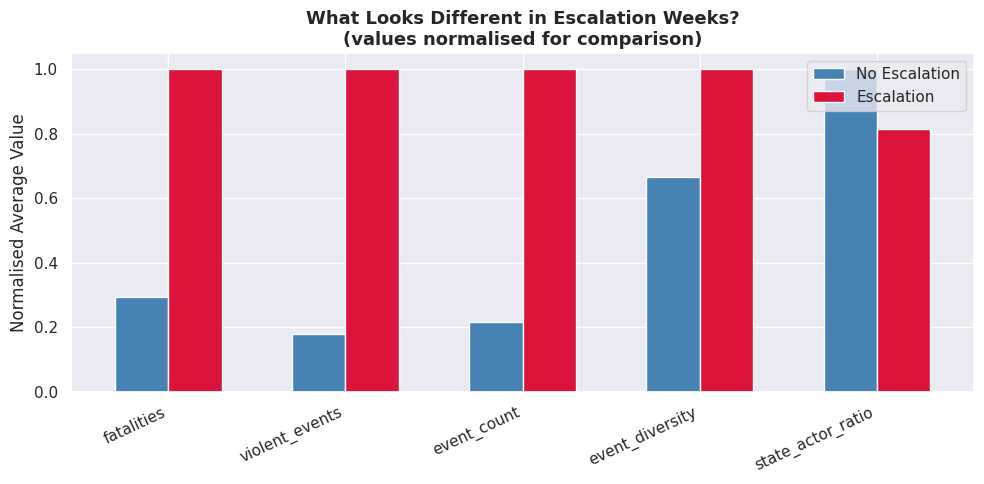

In [28]:
# 4. WHAT DRIVES ESCALATION? — SIMPLE GROUPED BAR
# Average feature values for escalated vs non-escalated weeks
# ─────────────────────────────────────────────
compare_cols = [
    "fatalities", "violent_events", "event_count",
    "event_diversity", "state_actor_ratio"
]

grouped = (
    weekly_df.groupby("conflict_escalation")[compare_cols]
    .mean()
    .T
    .rename(columns={0: "No Escalation", 1: "Escalation"})
)

# Normalise to 0-1 for fair comparison across different scales
grouped_norm = grouped.div(grouped.max(axis=1), axis=0)

grouped_norm.plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "crimson"],
    edgecolor="white",
    width=0.6
)
plt.title("What Looks Different in Escalation Weeks?\n(values normalised for comparison)",
          fontsize=13, fontweight="bold")
plt.ylabel("Normalised Average Value")
plt.xticks(rotation=25, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()


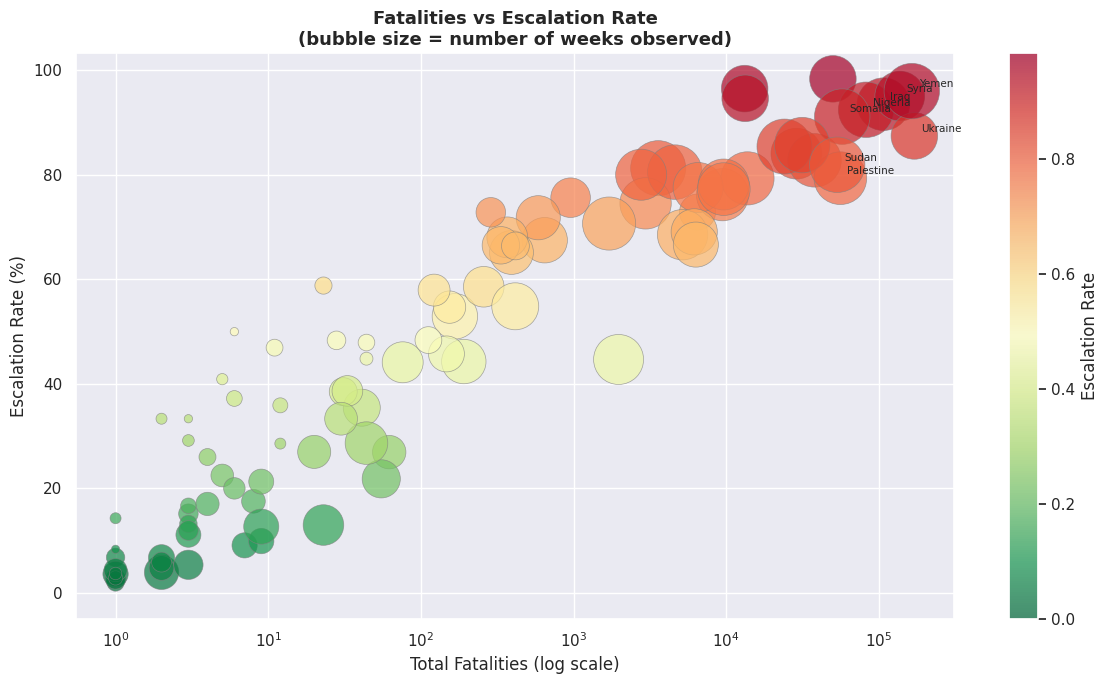

In [30]:
# 2. FATALITIES vs ESCALATION RATE BUBBLE CHART
# Big bubbles = more conflict weeks on record
# ─────────────────────────────────────────────
country_stats = weekly_df.groupby("country").agg(
    total_fatalities=("fatalities", "sum"),
    escalation_rate=("conflict_escalation", "mean"),
    weeks=("conflict_escalation", "count")
).reset_index()

# Focus on countries with enough data
country_stats = country_stats[country_stats["weeks"] >= 10]

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    country_stats["total_fatalities"],
    country_stats["escalation_rate"] * 100,
    s=country_stats["weeks"] * 3,
    c=country_stats["escalation_rate"],
    cmap="RdYlGn_r",
    alpha=0.7,
    edgecolors="gray",
    linewidths=0.5
)

# Label the most extreme countries
top = country_stats.nlargest(8, "total_fatalities")
for _, row in top.iterrows():
    plt.annotate(
        row["country"],
        (row["total_fatalities"], row["escalation_rate"] * 100),
        fontsize=7.5, ha="left",
        xytext=(5, 3), textcoords="offset points"
    )

plt.colorbar(scatter, label="Escalation Rate")
plt.xscale("log")
plt.xlabel("Total Fatalities (log scale)")
plt.ylabel("Escalation Rate (%)")
plt.title("Fatalities vs Escalation Rate\n(bubble size = number of weeks observed)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()